<a href="https://colab.research.google.com/github/HappyGithub-dev/Digital-Stethoscope-App/blob/main/DataPipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import os
import glob
import pandas as pd
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive', force_remount=False)

# 2. Folder path
drive_path = '/content/drive/MyDrive/Echo Chest Analysis'

# 3. Ground truth heart rates with filename variant aliases included
pulse_data = {
    "Abhishek Mandal": 116, "Ajay Kumar": 72, "Anand": 116, "Ashish Sinha": 106,
    "Aziz": 89, "Bhoomika": 100, "Bhuvana": 95, "Gopu Siva": 114, "Jaya": 95,
    "Kanailal": 106, "Lavanya": 102, "Madhu Babu": 86, "Majeed": 96,
    "Manesh Kumar": 112, "Meenakshi": 66, "Mohan": 95, "Navaz": 83,
    "Nikhil": 120, "Nitish": 115, "Nithish": 100, "Pradeep": 80, "Priya": 83,
    "Rajath Kumar": 77, "Rajeshwari": 73, "Rajeswari": 73, "Rajeshwari C": 110,
    "Rajeswari.c": 110, "Ramya": 68, "Rasheed": 85, "Rishika": 81,
    "Sai Kiran": 92, "Sanish": 65, "Satish Kumar": 112, "Sathish kumar": 112,
    "Satish": 80, "Shahnavas": 78, "Shailendra": 88, "Siva Sankar": 67,
    "Siva": 82, "Sree Lekha": 70, "Srikanth": 105, "Swapna": 79,
    "Vandana Pydah": 90, "Y Blessi": 116
}

sorted_names = sorted(pulse_data.keys(), key=len, reverse=True)

# 4. Scan and pair files
pcg_files = sorted(glob.glob(f"{drive_path}/PCG_*.wav"))

rows = []
subject_idx = 1

for pcg_path in pcg_files:
    pcg_name = os.path.basename(pcg_path)
    identifier = pcg_name.replace("PCG_", "").replace(".wav", "")
    scg_name = f"SCG_{identifier}.csv"
    scg_path = os.path.join(drive_path, scg_name)

    if os.path.exists(scg_path):
        true_hr = None
        for name in sorted_names:
            formatted_name = name.replace(" ", "_")
            if formatted_name.lower() in pcg_name.lower():
                true_hr = pulse_data[name]
                break

        rows.append({
            "subject_id": f"P{subject_idx:02d}",
            "pcg_file": pcg_name,
            "scg_file": scg_name,
            "true_hr": true_hr,
            "true_rr": ""
        })
        subject_idx += 1
    else:
        print(f"⚠️ Missing SCG match for: {pcg_name}")

# 5. Export master tracker
df_master = pd.DataFrame(rows)
tracker_output_path = os.path.join(drive_path, "master_tracker.csv")
df_master.to_csv(tracker_output_path, index=False)

# 6. Sanity check output
missing_hr = df_master[df_master['true_hr'].isna()]
print(f"\n✅ Created master_tracker.csv with {len(df_master)} paired profiles.")
if not missing_hr.empty:
    print(f"⚠️ Warning: {len(missing_hr)} profiles did not match any ground truth name:")
    print(missing_hr['pcg_file'].tolist())
else:
    print("🎯 All 40 subjects matched with their true ground truth heart rate!")

df_master.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ Created master_tracker.csv with 40 paired profiles.
🎯 All 40 subjects matched with their true ground truth heart rate!


,subject_id,pcg_file,scg_file,true_hr,true_rr
0,P01,PCG_Abhishek_Mandal_M_25_16-Jun-2026_1.wav,SCG_Abhishek_Mandal_M_25_16-Jun-2026_1.csv,116,
1,P02,PCG_Ajay_Kumar_12-Jun-2026_1.wav,SCG_Ajay_Kumar_12-Jun-2026_1.csv,72,
2,P03,PCG_Anand_12-Jun-2026_1.wav,SCG_Anand_12-Jun-2026_1.csv,116,
3,P04,PCG_Ashish_Sinha_12-Jun-2026_1.wav,SCG_Ashish_Sinha_12-Jun-2026_1.csv,106,
4,P05,PCG_Aziz_M_25_16-Jun-2026_1.wav,SCG_Aziz_M_25_16-Jun-2026_1.csv,89,


In [17]:
import os
import numpy as np
import pandas as pd
from scipy.signal import butter, sosfiltfilt, hilbert, find_peaks
import librosa

# 1. Setup Paths
drive_path = '/content/drive/MyDrive/Echo Chest Analysis'
tracker_path = os.path.join(drive_path, 'master_tracker.csv')
output_path = os.path.join(drive_path, 'extracted_features.csv')

df = pd.read_csv(tracker_path)

# 2. DSP Functions (Upgraded for Stability)
def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    # FIX: Using 'sos' (Second-Order Sections) prevents numerical underflow
    sos = butter(order, [low, high], btype='band', output='sos')
    return sosfiltfilt(sos, data)

def extract_hr_and_snr(signal_data, fs, is_audio=True):
    lowcut = 20.0 if is_audio else 1.0
    highcut = 150.0 if is_audio else 20.0

    filtered_signal = butter_bandpass_filter(signal_data, lowcut, highcut, fs)

    analytic_signal = hilbert(filtered_signal)
    amplitude_envelope = np.abs(analytic_signal)

    distance = int(fs / (180 / 60))

    # Add a tiny safety offset to the mean to prevent finding micro-noise peaks
    threshold = np.mean(amplitude_envelope) * 1.1
    peaks, _ = find_peaks(amplitude_envelope, distance=distance, height=threshold)

    if len(peaks) > 1:
        avg_peak_interval = np.mean(np.diff(peaks)) / fs
        hr_bpm = 60.0 / avg_peak_interval
    else:
        hr_bpm = 0

    signal_power = np.mean(amplitude_envelope[peaks]**2) if len(peaks) > 0 else 0
    noise_power = np.mean(amplitude_envelope**2)
    snr_db = 10 * np.log10(signal_power / noise_power) if noise_power > 0 and signal_power > 0 else 0

    return round(hr_bpm, 2), round(snr_db, 2)

# 3. Execution Loop
features = []

print(f"Processing {len(df)} patient files. This will be fast...\n")

for index, row in df.iterrows():
    subject = row['subject_id']
    pcg_path = os.path.join(drive_path, row['pcg_file'])
    scg_path = os.path.join(drive_path, row['scg_file'])

    try:
        # FIX: Downsample audio to 2000Hz on load for filter stability
        audio_data, fs_audio = librosa.load(pcg_path, sr=2000)
        pcg_hr, pcg_snr = extract_hr_and_snr(audio_data, fs_audio, is_audio=True)

        scg_df = pd.read_csv(scg_path)
        z_col = scg_df.columns[2] if 'z' not in scg_df.columns else 'z'
        scg_data = scg_df[z_col].values
        fs_scg = 100
        scg_hr, scg_snr = extract_hr_and_snr(scg_data, fs_scg, is_audio=False)

        features.append({
            'subject_id': subject,
            'True_HR': row['true_hr'],
            'PCG_HR': pcg_hr,
            'PCG_SNR_dB': pcg_snr,
            'SCG_HR': scg_hr,
            'SCG_SNR_dB': scg_snr,
        })
        print(f"✅ Processed {subject} | True HR: {row['true_hr']} | PCG: {pcg_hr} | SCG: {scg_hr}")

    except Exception as e:
        print(f"❌ Error processing {subject}: {e}")

# 4. Save the Final Matrix
df_features = pd.DataFrame(features)
df_features.to_csv(output_path, index=False)
print(f"\n🎉 DSP Pipeline Complete! Saved to: {output_path}")

Processing 40 patient files. This will be fast...

✅ Processed P01 | True HR: 116 | PCG: 128.53 | SCG: 111.22
✅ Processed P02 | True HR: 72 | PCG: 131.27 | SCG: 69.66
✅ Processed P03 | True HR: 116 | PCG: 124.39 | SCG: 112.68
✅ Processed P04 | True HR: 106 | PCG: 132.15 | SCG: 106.46
✅ Processed P05 | True HR: 89 | PCG: 132.78 | SCG: 78.6
✅ Processed P06 | True HR: 100 | PCG: 139.95 | SCG: 105.33
✅ Processed P07 | True HR: 95 | PCG: 133.12 | SCG: 92.4
✅ Processed P08 | True HR: 114 | PCG: 132.58 | SCG: 107.11
✅ Processed P09 | True HR: 95 | PCG: 137.64 | SCG: 89.28
✅ Processed P10 | True HR: 106 | PCG: 133.25 | SCG: 95.33
✅ Processed P11 | True HR: 102 | PCG: 125.73 | SCG: 65.64
✅ Processed P12 | True HR: 86 | PCG: 133.89 | SCG: 68.87
✅ Processed P13 | True HR: 96 | PCG: 136.32 | SCG: 94.85
✅ Processed P14 | True HR: 112 | PCG: 124.08 | SCG: 117.29
✅ Processed P15 | True HR: 66 | PCG: 116.81 | SCG: 46.92
✅ Processed P16 | True HR: 95 | PCG: 137.6 | SCG: 97.06
✅ Processed P17 | True HR:

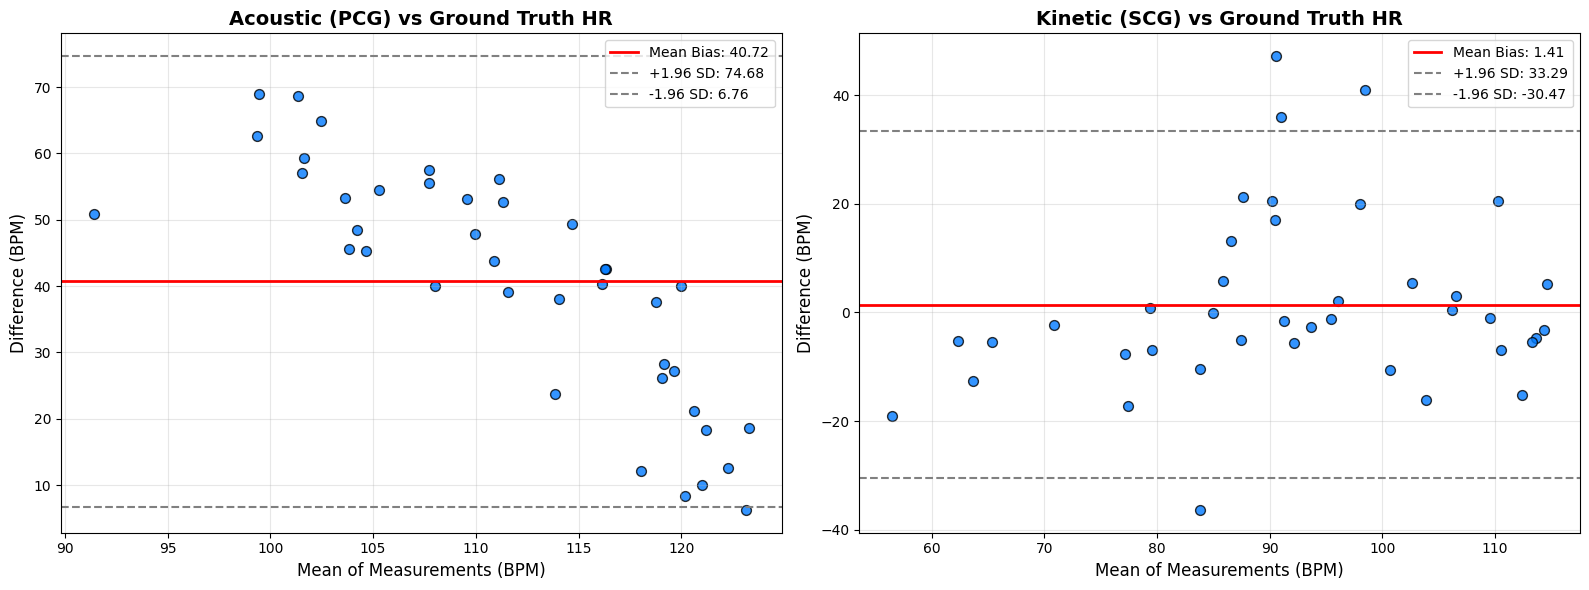


🧠 MACHINE LEARNING EVALUATION (Random Forest)
Model Accuracy (R² Score): 0.872

Feature Predictive Power (Which sensor metric matters most?):
 🔹 SCG_HR: 51.4%
 🔹 PCG_HR: 24.5%
 🔹 SCG_SNR_dB: 12.4%
 🔹 PCG_SNR_dB: 11.7%


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. Load the finalized matrix
df = pd.read_csv('/content/drive/MyDrive/Echo Chest Analysis/extracted_features.csv')

# Filter out any absolute zero anomalies just to be safe
df_clean = df[(df['PCG_HR'] > 0) & (df['SCG_HR'] > 0)].copy()

# --- BLAND-ALTMAN STATISTICAL ANALYSIS ---
def plot_bland_altman(modal_1, modal_2, title, ax):
    mean_vals = np.mean([modal_1, modal_2], axis=0)
    diff_vals = modal_1 - modal_2
    mean_diff = np.mean(diff_vals)
    std_diff = np.std(diff_vals)

    ax.scatter(mean_vals, diff_vals, alpha=0.8, c='#007AFF', edgecolors='black', s=50)
    ax.axhline(mean_diff, color='red', linestyle='-', linewidth=2, label=f'Mean Bias: {mean_diff:.2f}')
    ax.axhline(mean_diff + 1.96 * std_diff, color='gray', linestyle='--', label=f'+1.96 SD: {mean_diff + 1.96 * std_diff:.2f}')
    ax.axhline(mean_diff - 1.96 * std_diff, color='gray', linestyle='--', label=f'-1.96 SD: {mean_diff - 1.96 * std_diff:.2f}')

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Mean of Measurements (BPM)', fontsize=12)
    ax.set_ylabel('Difference (BPM)', fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_bland_altman(df_clean['PCG_HR'], df_clean['True_HR'], 'Acoustic (PCG) vs Ground Truth HR', axes[0])
plot_bland_altman(df_clean['SCG_HR'], df_clean['True_HR'], 'Kinetic (SCG) vs Ground Truth HR', axes[1])
plt.tight_layout()
plt.show()

# --- RANDOM FOREST MACHINE LEARNING ---
print("\n" + "="*50)
print("🧠 MACHINE LEARNING EVALUATION (Random Forest)")
print("="*50)

# Define our inputs (features) and our target (True HR)
X = df_clean[['PCG_HR', 'SCG_HR', 'PCG_SNR_dB', 'SCG_SNR_dB']]
y = df_clean['True_HR']

# Train the model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# Calculate overall accuracy
y_pred = rf.predict(X)
r2 = r2_score(y, y_pred)
print(f"Model Accuracy (R² Score): {r2:.3f}\n")

# Extract what the AI found most important
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Feature Predictive Power (Which sensor metric matters most?):")
for feat, imp in importances.items():
    print(f" 🔹 {feat}: {imp*100:.1f}%")
print("="*50)